The purpose of this file is to test various strategies and algorithms. Each one will do paper-trading by using past performance of various ETFs and companies as the trading field, using data from 2020 to 2025 (5 years). The purpose of this file is to try and discover an effective strategy before implementing it in the real world.

**Data Gathering**

First, gather all of the data of various tickers, and store them in .csv files in a data folder so that they can be later loaded using pandas. Doing this seperately allows us to only run the data gathering part once, only having to do so again if we change which tickers we want to test with, or if we need to update the data range. The data will be gahtered from yahoo finance.

In [12]:
# Initial Imports
import yfinance as yf
import os

In [13]:
# The tickers to use and the date range.
tickers = ["AAPL", "GOOG", "KOD", "MDB", "NVDA", "SGLN", "SPY"]

startDate = "2020-01-01"
endDate = "2025-12-31"

In [14]:
# Make sure that the data folder exists.
if not os.path.isdir("data"):
    os.mkdir("data")

In [15]:
# Downloading and saving tickers.
for ticker in tickers:
    try:
        data = yf.download(ticker, start=startDate, end=endDate)
        data.to_csv(f"data/{ticker}.csv")
        print(f"Downloaded {ticker}.")
    except Exception as e:
        print(f"Error downloading {ticker}: {e}")

[*********************100%***********************]  1 of 1 completed


Downloaded AAPL.


[*********************100%***********************]  1 of 1 completed


Downloaded GOOG.


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

...

Downloaded NVDA.


[*********************100%***********************]  1 of 1 completed


Downloaded SGLN.


[*********************100%***********************]  1 of 1 completed

Downloaded SPY.


**Simulation Construction**

Now that we have the data, we'll build a class that we can use for constructing a simulation. The simulation will simply go through each point in time, adjusting stocks, prices, and overall portfolio value with each step through time. Each step will also return the total portfolio value at the end of that time step, allowing us to eventually visualise it as a graph.

In [16]:
# Initial Imports
import pandas as pd
from datetime import date, timedelta, datetime

In [17]:
# First, load the data into a "Data" class.
# Once again, we use a seperate class so that we don't have to re-run the code every time.

class Data:
    def __init__(self):
        self.data = {}

        for ticker in tickers:
            data = pd.read_csv(f"data/{ticker}.csv", parse_dates = True)

            # The first two rows have garbage data, so we can ignore them.
            data = data[2:].reset_index(drop = True)
            data = data.rename(columns={"Price": "Date"})

            self.data[ticker] = data

    def recieve_ticker_info(self, ticker, date):
        index = date.strftime("%Y-%m-%d")
        dataObject = self.data[ticker]

        foundValues = dataObject[dataObject["Date"] == index]

        if len(foundValues) <= 0:
            return None

        foundValues = foundValues.iloc[0]

        return {
            "OPEN": float(foundValues["Open"]),
            "LOW": float(foundValues["Low"]),
            "HIGH": float(foundValues["High"]),
            "CLOSE": float(foundValues["Close"]),
            "VOLUME": float(foundValues["Volume"])
        }

dataObject = Data() # Will be passed into every Simulation instance we make.

In [18]:
# The Simulation class will represent a single instance of a portfolio, allowing us to simulate growth.

class Simulation:
    def __init__(self, dataObject, startingValue = 1000):
        self.dataObject = dataObject
        self.tickers = list(self.dataObject.data.keys())
        
        self.baseStockInfo = {}
        self.currentStockInfo = {}
        
        self.looseCash = startingValue
        self.heldStocks = {}

        self.currentDate = datetime.strptime(startDate, "%Y-%m-%d")
        self.endDate = datetime.strptime(endDate, "%Y-%m-%d")
        self.portfolioWorth = []

        self.generate_data()

    def generate_data(self):
        self.currentStockInfo = {}
        
        for ticker in self.tickers:
            data = self.dataObject.recieve_ticker_info(ticker, self.currentDate)

            if data != None:
                self.baseStockInfo[ticker] = data

            self.currentStockInfo[ticker] = data

    def buy_stocks(self, ticker, amount, endOfDay = False):
        if not ticker in self.currentStockInfo or self.currentStockInfo[ticker] == None:
            return

        amount = max(0, min(amount, self.looseCash))

        if not ticker in self.heldStocks:
            self.heldStocks[ticker] = 0

        self.heldStocks[ticker] += amount / self.currentStockInfo[ticker]["CLOSE" if endOfDay else "OPEN"]
        self.looseCash -= amount

    def sell_stocks(self, ticker, amount, endOfDay = False):
        if not ticker in self.baseStockInfo or self.baseStockInfo[ticker] == None or not ticker in self.heldStocks:
            return

        amount = max(0, min(self.heldStocks[ticker], amount))
        self.looseCash += amount * self.baseStockInfo[ticker]["CLOSE" if endOfDay else "OPEN"]
        self.heldStocks[ticker] -= amount
        

    def get_portfolio_value(self):
        value = self.looseCash

        for stock in self.heldStocks.keys():
            if not stock in self.baseStockInfo or not stock in self.heldStocks:
                continue

            value += self.heldStocks[stock] * self.baseStockInfo[stock]["CLOSE"]

        return value

    def advance_day(self):
        value = self.get_portfolio_value()
        self.portfolioWorth.append(value)
        self.currentDate += timedelta(days = 1)
        self.generate_data()

    
    def simulate(self, strategy):
        while self.currentDate < self.endDate:
            strategy.use_strategy(self)
            self.advance_day()

In [19]:
# Last, the Strategy class defines what to do at each moment, using current stock info as a teller.
class Strategy:
    def __init__(self):
        pass

    def use_strategy(self, simulation):
        pass

**Displaying Results**

We'll use matplotlib and numpy together to display the final results of our strategies all on the same graph, making it easier to tell how they performed when put against each other, and which one performed the best.

In [20]:
# Initial imports.
import matplotlib.pyplot as plt

In [21]:
def display_performances(simulations):
    for simulation in simulations.keys():
        values = simulations[simulation].portfolioWorth
        plt.plot(values, label = simulation)

    plt.legend(loc = "upper left")
    plt.grid(True)
    plt.show()

**Initial Setup**

The main strategy that most people rely on is the "Buy & Hold" strategy, where you simply keep buying into stocks and not let go of them no matter what. We'll build and test both this strategy and also just not buying anything as a control.

For reference, each simulation will assume that we have £100 to start with, and are adding £1 every day (so about £30 every month). These numbers were chosen as a low-ball estimate, as I feel like this is the usual amount most people would be investing, especially those who are financially challenged.

In [22]:
# This new simulation will simply have that 1000 pound start, along with the +£10 every day.
class Test_Simulation(Simulation):
    def __init__(self, dataObject):
        super().__init__(dataObject, 100)

    def advance_day(self):
        super().advance_day()
        self.looseCash += 1

In [23]:
"""
Strategy #1 - Control Strategy.

The control for the simulation just to see what would happen if we did absolutely nothing.
"""

class Control_Strategy(Strategy):
    def use_strategy(self, simulation):
        pass

In [24]:
"""
Strategy #2 - Buy & Hold.

Every time we have loose cash, we'll evenly buy into each and every stock and hold them. We'll never sell, either.
"""

class Buy_And_Hold_Strategy(Strategy):
    def use_strategy(self, simulation):
        availableTickers = []

        for ticker in simulation.currentStockInfo.keys():
            if simulation.currentStockInfo[ticker] != None:
                availableTickers.append(ticker)
        
        if len(availableTickers) <= 0:
            return
        
        toSpend = simulation.looseCash / len(availableTickers)

        for ticker in availableTickers:
            simulation.buy_stocks(ticker, toSpend)

In [25]:
# Simulate both strategies.
strategies = {
    "Control": Control_Strategy(),
    "Buy And Hold": Buy_And_Hold_Strategy()
}

simulations = {}

for strategy in strategies.keys():
    newSim = Test_Simulation(dataObject)
    newSim.simulate(strategies[strategy])
    simulations[strategy] = newSim

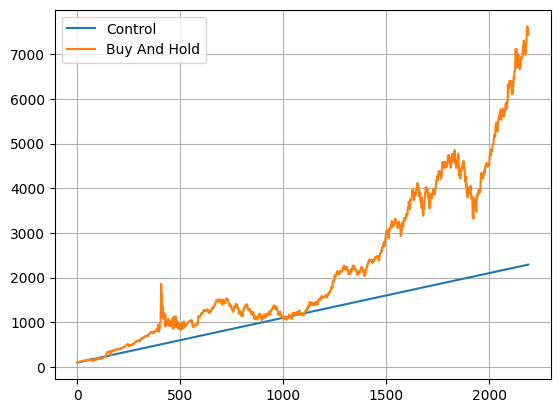

In [26]:
display_performances(simulations)

**Strategy Set #1: Hardcoding**

The first set of strategies we'll implement are basic, hardcoded strategies. This has no neutral networosk or artificial intelligence, and are practically equivalent to just scripts that the computer will follow to a T. Algorithms, effectively.

The idea here is to experiment with different strategies so that later on, we know that kind of strategies generally are more effective, and can fine-tune agents around that.

In [334]:
"""
Strategy #1.1 - Buy Lowest & Hold.

Equivalent to the standard "Buy & Hold", however with the added rule that we'll buy the lowest stock each
time, hoepfully maximising our value.
"""

class Buy_Lowest_And_Hold_Strategy(Strategy):
    def use_strategy(self, simulation):
        availableTickers = []

        for ticker in simulation.currentStockInfo.keys():
            if simulation.currentStockInfo[ticker] != None:
                availableTickers.append(ticker)
        
        if len(availableTickers) <= 0:
            return
        
        availableTickers.sort(key = lambda x: simulation.currentStockInfo[x]["OPEN"])
        simulation.buy_stocks(availableTickers[0], simulation.looseCash)

In [335]:
"""
Strategy #1.2 - Buy Lowest & Sell Highest.

Like the previous strategy, however with the added rule that we always try to sell the highest stock
based on closing values.
"""

class Buy_Lowest_And_Sell_Highest_Strategy(Strategy):
    def use_strategy(self, simulation):
        availableTickers = []

        for ticker in simulation.currentStockInfo.keys():
            if simulation.currentStockInfo[ticker] != None:
                availableTickers.append(ticker)
        
        if len(availableTickers) <= 0:
            return

        # First, buy the lowest.
        availableTickers.sort(key = lambda x: simulation.currentStockInfo[x]["OPEN"])
        simulation.buy_stocks(availableTickers[0], simulation.looseCash)

        # Then, sell the highest.
        availableTickers = [ticker for ticker in availableTickers if ticker in simulation.heldStocks]

        if len(availableTickers) <= 0:
            return
        
        availableTickers.sort(key = lambda x: simulation.currentStockInfo[x]["CLOSE"])
        simulation.sell_stocks(availableTickers[-1], simulation.heldStocks[availableTickers[-1]], endOfDay = True)

In [336]:
"""
Strategy #1.3 - Sell All, Buy Lowest

A very, VERY aggressive strategy that goes all-in on the lowest stock and sells everything whenever
possible.
"""

class Sell_All_Buy_Lowest_Strategy(Strategy):
    def use_strategy(self, simulation):
        availableTickers = []

        for ticker in simulation.currentStockInfo.keys():
            if simulation.currentStockInfo[ticker] != None:
                availableTickers.append(ticker)
        
        if len(availableTickers) <= 0:
            return

        # First, we'll buy the lowest.
        availhttps://www.argos.co.uk/product/1484027ableTickers.sort(key = lambda x: simulation.currentStockInfo[x]["OPEN"])
        simulation.buy_stocks(availableTickers[0], simulation.looseCash)

        # Then, sell EVERYTHING at the end of the day.
        for ticker in simulation.currentStockInfo.keys():
            if ticker in simulation.heldStocks:
                simulation.sell_stocks(ticker, simulation.heldStocks[ticker], endOfDay = True)

In [337]:
# Simulate strategies.
strategies = {
    "Buy Lowest And Hold": Buy_Lowest_And_Hold_Strategy(),
    "Buy Lowest, Sell Highest": Buy_Lowest_And_Sell_Highest_Strategy(),
    "Sell All, Buy Lowest": Sell_All_Buy_Lowest_Strategy()
}

for strategy in strategies.keys():
    newSim = Test_Simulation(dataObject)
    newSim.simulate(strategies[strategy])
    simulations[strategy] = newSim

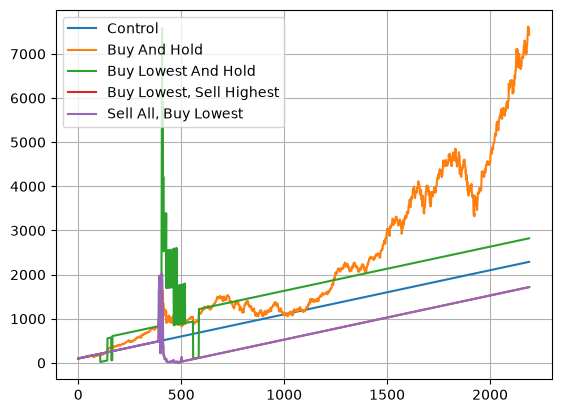

In [338]:
display_performances(simulations)

In [339]:
# Strategy Performance
simulationRankings = [simulation for simulation in (simulations.keys())]
simulationRankings.sort(key = lambda x: simulations[x].get_portfolio_value())

for simulation in simulationRankings:
    print(f"{simulation}: {simulations[simulation].get_portfolio_value()}")

Buy Lowest, Sell Highest: 1718.715825428912
Sell All, Buy Lowest: 1718.715825428912
Control: 2291
Buy Lowest And Hold: 2824.223412153759
Buy And Hold: 7437.4137697188235


**Strategy Set 2: Static Machine Learning**

Since hard-coded strategies can only go so far, the next approach is to use machine learning
in order to handle it. Static machine learning models learn first, and execute afterwards. Meanwhile, dynamic models learn and execute at the same time, often being more complicated as a result. This section will focus on various static machine learning models, and will also extend the original simulation as a gym for training purposes.

In [27]:
import numpy as np

import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim

In [60]:
class SimulationEnv(gym.Env):
    def __init__(self, dataObject, render_mode = None):
        self.dataObject = dataObject
        tickers = len(list(dataObject.data.keys()))

        self.simulation = Test_Simulation(dataObject)
        
        self.action_space = spaces.Dict({
            "chosen_actions": spaces.MultiDiscrete([3 for _ in range(tickers)]),
            "magnitude": spaces.Box(low = 0, high = 1, shape = (tickers,), dtype = np.float32),
            "hold_magnitude": spaces.Box(low = 0, high = 1, shape = (1,), dtype = np.float32)
        })

        self.observation_space = spaces.Dict({
            "open_values": spaces.Box(low = 0, high = np.inf, shape=(tickers,), dtype = np.float32),
            "close_values": spaces.Box(low = 0, high = np.inf, shape=(tickers,), dtype = np.float32),
            "is_open": spaces.MultiDiscrete([2 for _ in range(tickers)])
        })
        self.render_mode = render_mode

    def construct_observation(self):
        tickers = list(self.dataObject.data.keys())
        obs = {
            "open_values": [],
            "close_values": [],
            "is_open": []
        }

        for ticker in tickers:
            isOpen = 1 if self.simulation.currentStockInfo[ticker] != None else 0
            obs["is_open"].append(isOpen)

            if isOpen == 0:
                if not ticker in self.simulation.baseStockInfo:
                    obs["open_values"].append(99999)
                    obs["close_values"].append(99999)

                else:
                    obs["open_values"].append(self.simulation.baseStockInfo[ticker]["OPEN"])
                    obs["close_values"].append(self.simulation.baseStockInfo[ticker]["CLOSE"])
            else:
                obs["open_values"].append(self.simulation.currentStockInfo[ticker]["OPEN"])
                obs["close_values"].append(self.simulation.currentStockInfo[ticker]["CLOSE"])

        obs = {
            "open_values": np.array(obs["open_values"]),
            "close_values": np.array(obs["open_values"]),
            "is_open": np.array(obs["open_values"])
        }

        return obs

    
    def reset(self, seed = None, options = None):
        self.simulation = Test_Simulation(dataObject)
        self.simulation.generate_data()
        obs = self.construct_observation()
        return obs, {}
        

    def step(self, action):
        tickers = list(dataObject.data.keys())
        totalDistribution = action["hold_magnitude"][0]
        originalCash = self.simulation.looseCash

        for magnitude in action["magnitude"]:
            totalDistribution += magnitude
        
        for i, tickerAction in enumerate(action["chosen_actions"]):
            ticker = tickers[i]
            
            if tickerAction == 0 or (tickerAction == 2 and not ticker in self.simulation.heldStocks):
                continue

            if tickerAction == 1:
                self.simulation.buy_stocks(ticker, (action["magnitude"][i] / totalDistribution) * originalCash)
            else:
                self.simulation.sell_stocks(ticker, action["magnitude"][i] * self.simulation.heldStocks[ticker])

        self.simulation.advance_day()
        obs = self.construct_observation()
        reward = self.simulation.portfolioWorth[-1]
        terminated = self.simulation.currentDate >= self.simulation.endDate

        return obs, reward, terminated, False, {}